In [8]:
import pandas as pd

df = pd.read_csv("customer_churn_nn.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df["churn"].value_counts())
print(df["churn"].value_counts(normalize=True) * 100)

(2000, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.utils import resample
import numpy as np

X = df.drop(columns=["customer_id", "churn"])
y = df["churn"]

categorical_cols = ["region", "plan_type", "contract_type", "payment_method"]
numerical_cols = X.drop(columns=categorical_cols).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

train_data = np.column_stack([X_train_processed, y_train])
majority = train_data[train_data[:, -1] == 0]
minority = train_data[train_data[:, -1] == 1]

minority_upsampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42
)

balanced_train = np.vstack([majority, minority_upsampled])
np.random.shuffle(balanced_train)

X_train_balanced = balanced_train[:, :-1]
y_train_balanced = balanced_train[:, -1].astype(int)

In [10]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    batch_size=32,
    max_iter=100,
    random_state=42,
    early_stopping=True
)

model.fit(X_train_balanced, y_train_balanced)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(32, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


Training Accuracy: 0.9931
Training Loss: 0.0251

Testing Accuracy: 0.9725
Testing Loss: 0.0926

Confusion Matrix:
[[388   6]
 [  5   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       394
           1       0.14      0.17      0.15         6

    accuracy                           0.97       400
   macro avg       0.57      0.58      0.57       400
weighted avg       0.97      0.97      0.97       400



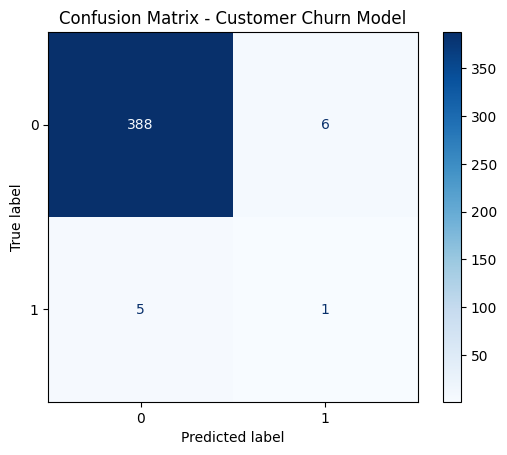

In [16]:
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

train_pred = model.predict(X_train_processed)
train_prob = model.predict_proba(X_train_processed)

predictions = model.predict(X_test_processed)
probabilities = model.predict_proba(X_test_processed)

train_accuracy = accuracy_score(y_train, train_pred)
train_loss = log_loss(y_train, train_prob)

test_accuracy = accuracy_score(y_test, predictions)
test_loss = log_loss(y_test, probabilities)

print("Training Accuracy:", round(train_accuracy, 4))
print("Training Loss:", round(train_loss, 4))

print("\nTesting Accuracy:", round(test_accuracy, 4))
print("Testing Loss:", round(test_loss, 4))

cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Blues"
)

plt.title("Confusion Matrix - Customer Churn Model")

plt.savefig("results/evaluation_outputs.png", bbox_inches="tight")

plt.show()

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, log_loss
import pandas as pd

def run_experiment(hidden_layers, activation, learning_rate, batch_size, epochs):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="adam",
        learning_rate_init=learning_rate,
        batch_size=batch_size,
        max_iter=epochs,
        random_state=42,
        early_stopping=True
    )

    model.fit(X_train_balanced, y_train_balanced)

    predictions = model.predict(X_test_processed)
    probabilities = model.predict_proba(X_test_processed)

    return {
        "Hidden Layers": str(hidden_layers),
        "Activation": activation,
        "Learning Rate": learning_rate,
        "Batch Size": batch_size,
        "Epochs": epochs,
        "Accuracy": round(accuracy_score(y_test, predictions), 4),
        "F1 Score": round(f1_score(y_test, predictions), 4),
        "Loss": round(log_loss(y_test, probabilities), 4)
    }

experiments = [
    run_experiment((16,), "relu", 0.001, 32, 100),
    run_experiment((32, 16), "relu", 0.001, 32, 100),
    run_experiment((32,), "tanh", 0.01, 32, 100),
    run_experiment((64, 32), "relu", 0.0005, 64, 150)
]

results = pd.DataFrame(experiments)
results.to_csv("results/model_comparison_table.csv", index=False)

print(results)

  Hidden Layers Activation  Learning Rate  Batch Size  Epochs  Accuracy  \
0         (16,)       relu         0.0010          32     100    0.9450   
1      (32, 16)       relu         0.0010          32     100    0.9725   
2         (32,)       tanh         0.0100          32     100    0.9725   
3      (64, 32)       relu         0.0005          64     150    0.9525   

   F1 Score    Loss  
0    0.1538  0.1364  
1    0.1538  0.0926  
2    0.1538  0.1109  
3    0.0952  0.1277  


The neural network learns the main values during its training process are weights and biases. The weights determine the contribution of each input feature to the prediction, and the biases are used to fine-tune the output to better capture the trends in the data.The weights are used to control the contribution of each input feature to the prediction, and biases are used to adjust the output of the model to capture the trends in the data.

The reason for using an activation function is that it enables the model to learn the non-linear patterns. If the neural network didn't have an activation function, despite having many layers, it would be essentially a linear model. The activation functions like ReLU and Tanh enabled the network to gain complex relationships between the features of the customers and their churn.

If the learning rate is too large, the model can adjust the weights to much of a degree, and it may not reach the optimum solution. This can cause training to be unstable. Too small a learning rate means that it takes a long time for the model to learn and may not get a good result after the number of epochs.

There was not much difference between the accuracy of the model with the training data and the accuracy when it was tested with the testing data, hence there was not much overfitting of the model. But even with such a large dataset, churned customers were still very underrepresented – there were much more retained customers than churned customers – making it difficult to predict churned customers. This indicates a good overall performance, with less success on the churn class minority. Other enhancements may consider more examples of churns, class weighting, or other balancing measures.